# **Part A**

In [2]:
#1
!pip install pandas --quiet


In [3]:
import pandas as pd

In [5]:
df=pd.read_csv("agriculture_yield_dataset.csv", sep =',')

In [7]:
(print(len(df)))

1500


In [8]:
print(df.shape)

(1500, 8)


In [18]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']


In [13]:
df.head(10)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [15]:
#2
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rainfall_mm            1500 non-null   float64
 1   temperature_c          1500 non-null   float64
 2   fertilizer_kg          1500 non-null   float64
 3   irrigation_hours       1500 non-null   float64
 4   soil_ph                1500 non-null   float64
 5   crop_type              1500 non-null   object 
 6   soil_type              1500 non-null   object 
 7   yield_ton_per_hectare  1500 non-null   float64
dtypes: float64(6), object(2)
memory usage: 93.9+ KB


In [19]:
print("Data Types:\n", df.dtypes)

Data Types:
 rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object


In [20]:
missing_values = df.isnull().sum()
print("\nMissing Values per column:\n", missing_values)

affected_columns = missing_values[missing_values > 0].index.tolist()
if affected_columns:
    print(f"\nColumns with missing values: {affected_columns}")
else:
    print("\nNo missing values found.")


Missing Values per column:
 rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

No missing values found.


In [21]:
#3)
# 1. Generate summary statistics for numerical features
desc_stats = df.describe()
display(desc_stats)

# 2. Feature with the highest mean value
highest_mean_feature = desc_stats.loc['mean'].idxmax()
print(f"Feature with the highest mean: {highest_mean_feature}")

# 3. Feature with the highest standard deviation
highest_std_feature = desc_stats.loc['std'].idxmax()
print(f"Feature with the highest standard deviation: {highest_std_feature}")

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


Feature with the highest mean: rainfall_mm
Feature with the highest standard deviation: rainfall_mm


# **Part 2**

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

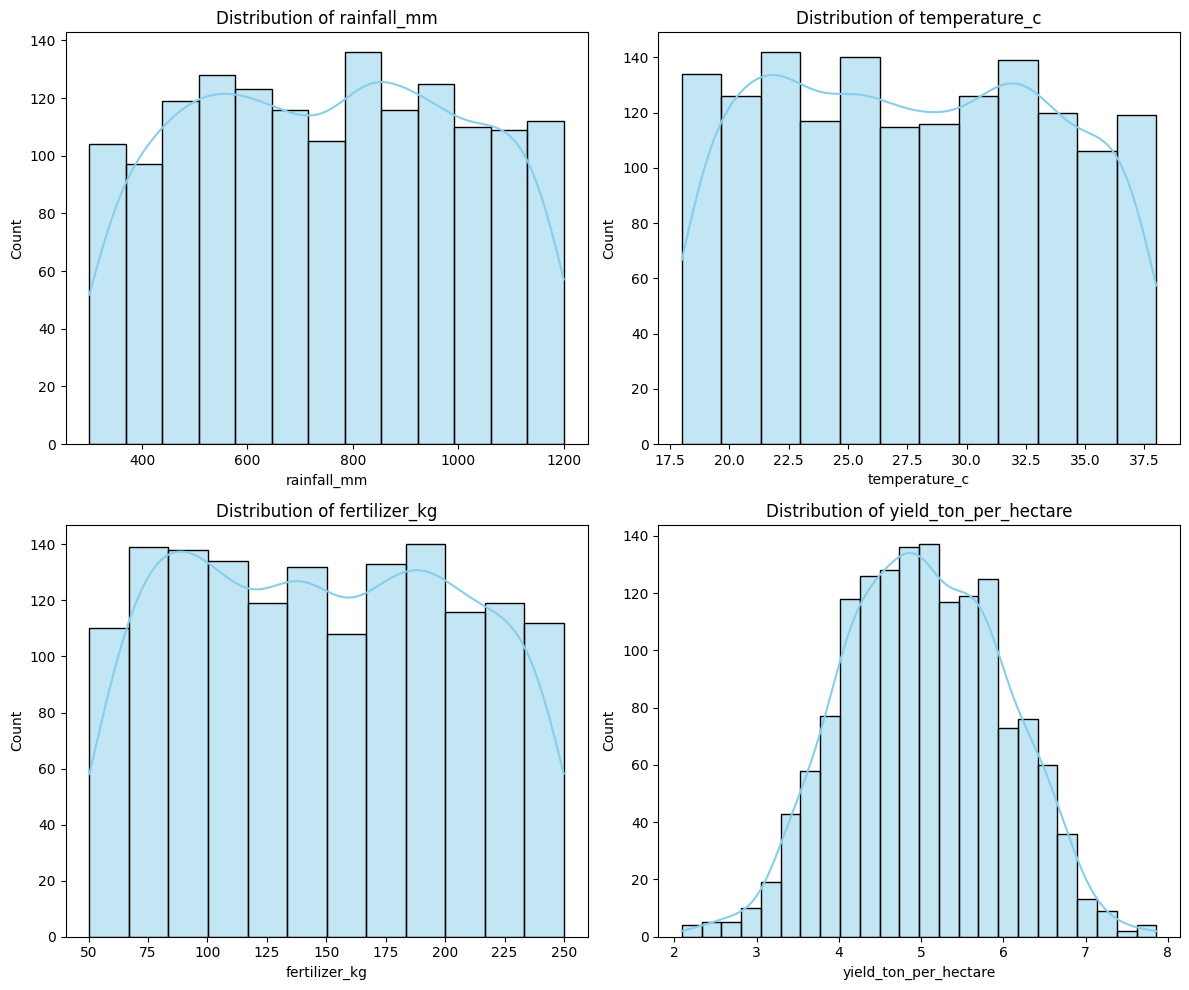

In [24]:
#4
features_to_plot = ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.histplot(df[feature], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

Records per crop type:
 crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


/tmp/ipykernel_6469/4160560682.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='crop_type', order=crop_counts.index, palette='viridis')


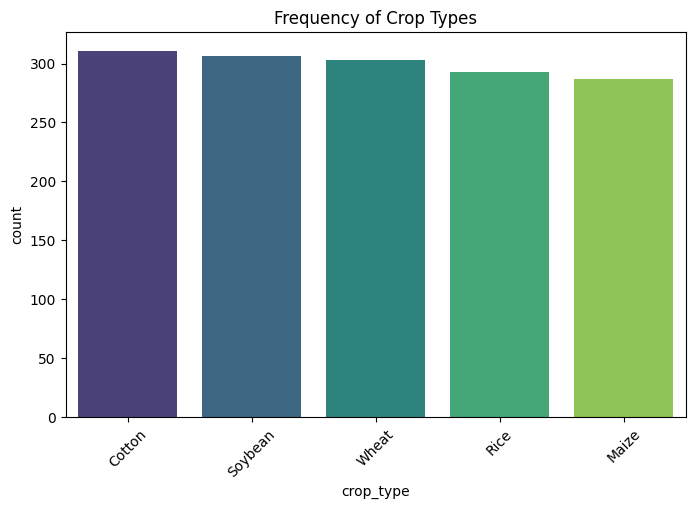

Most frequent crop: Cotton


In [25]:
#5)
# 1. Number of records for each crop type
crop_counts = df['crop_type'].value_counts()
print("Records per crop type:\n", crop_counts)

# 2. Create a count plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='crop_type', order=crop_counts.index, palette='viridis')
plt.title('Frequency of Crop Types')
plt.xticks(rotation=45)
plt.show()

# 3. Most frequent crop
print(f"Most frequent crop: {crop_counts.idxmax()}")

Records per soil type:
 soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


/tmp/ipykernel_6469/3536211982.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='soil_type', order=soil_counts.index, palette='magma')


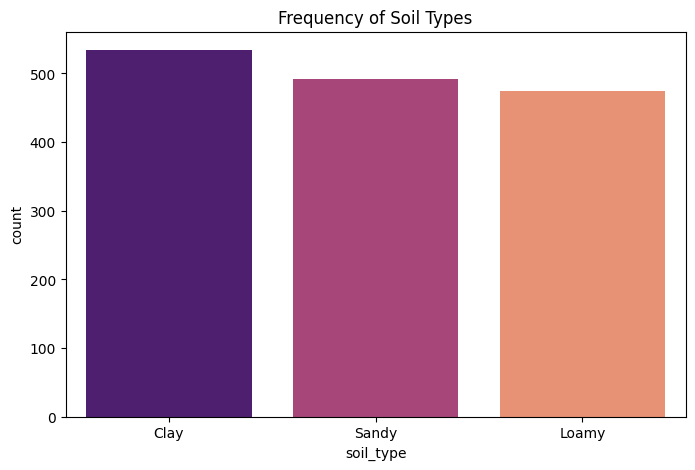

Most common soil type: Clay


In [26]:
#6
# 1. Frequency of each soil type
soil_counts = df['soil_type'].value_counts()
print("Records per soil type:\n", soil_counts)

# 2. Create a count plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='soil_type', order=soil_counts.index, palette='magma')
plt.title('Frequency of Soil Types')
plt.show()

# 3. Most common soil type
print(f"Most common soil type: {soil_counts.idxmax()}")

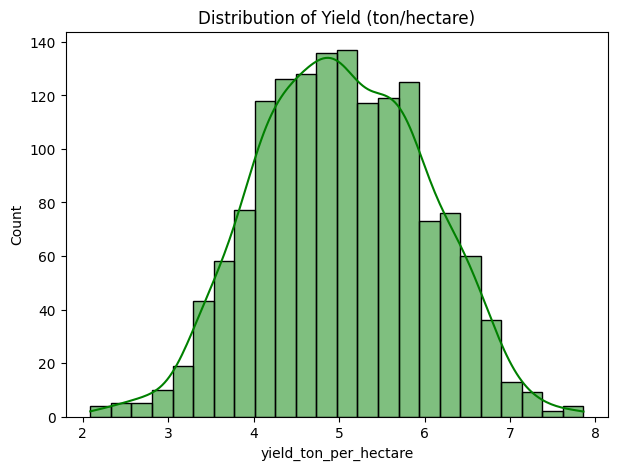

In [27]:
# 7)
#Histogram of yield
plt.figure(figsize=(7, 5))
sns.histplot(df['yield_ton_per_hectare'], kde=True, color='green')
plt.title('Distribution of Yield (ton/hectare)')
plt.show()

# Note: Inspect the plot to answer the questions about normality and outliers.

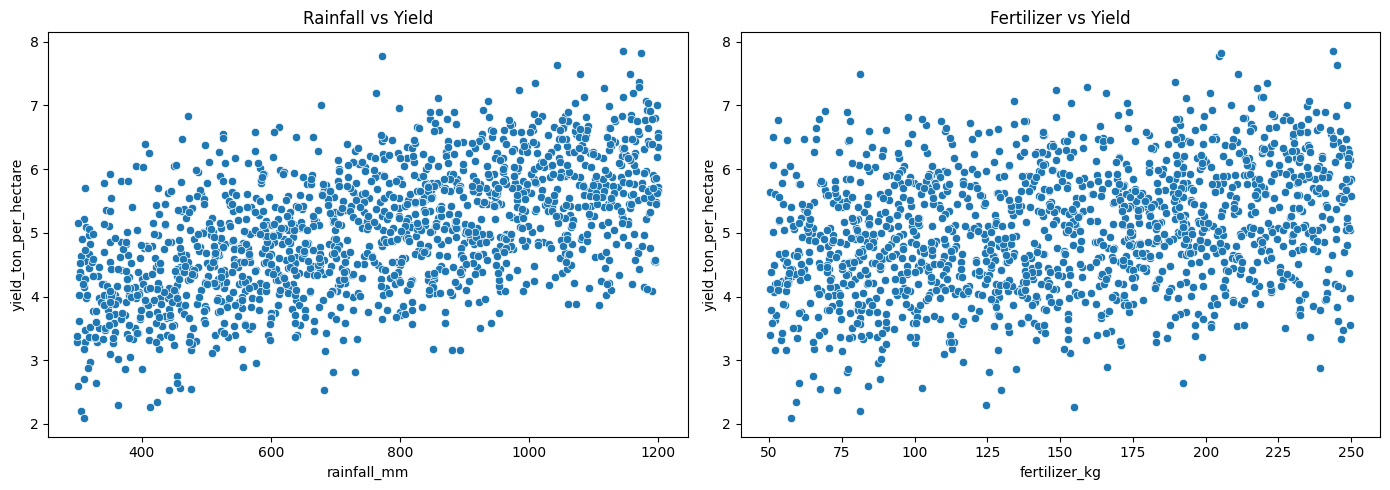

In [28]:
#8
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rainfall vs Yield
sns.scatterplot(data=df, x='rainfall_mm', y='yield_ton_per_hectare', ax=axes[0])
axes[0].set_title('Rainfall vs Yield')

# Fertilizer vs Yield
sns.scatterplot(data=df, x='fertilizer_kg', y='yield_ton_per_hectare', ax=axes[1])
axes[1].set_title('Fertilizer vs Yield')

plt.tight_layout()
plt.show()

# Note: You will visually determine which has a stronger relationship (tighter clustering/clearer trend).

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


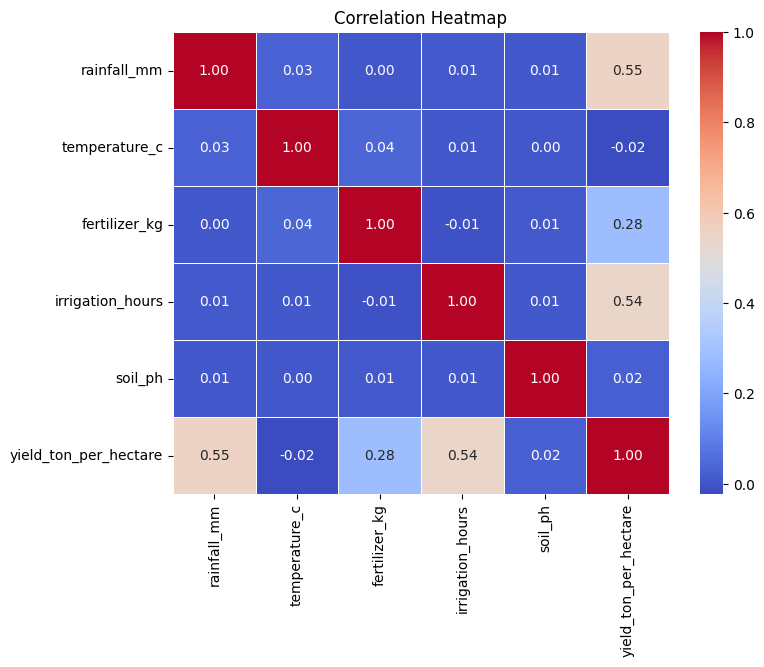

Top 3 features most correlated with yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [29]:
# 9)
#1. Generate correlation matrix (only for numerical columns)
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()
display(corr_matrix)

# 2. Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# 3. Top three features most correlated with yield
target_corr = corr_matrix['yield_ton_per_hectare'].drop('yield_ton_per_hectare').abs().sort_values(ascending=False)
print("Top 3 features most correlated with yield:")
print(target_corr.head(3))

In [30]:
#10)
# 1. Average yield for each crop type
avg_yield_crop = df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("Average yield by crop type:\n", avg_yield_crop)

# 2. Average yield for each soil type
avg_yield_soil = df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("\nAverage yield by soil type:\n", avg_yield_soil)

# 3. Highest average yield
print(f"\nCrop with highest average yield: {avg_yield_crop.idxmax()}")
print(f"Soil with highest average yield: {avg_yield_soil.idxmax()}")

Average yield by crop type:
 crop_type
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Maize      4.897143
Cotton     4.607299
Name: yield_ton_per_hectare, dtype: float64

Average yield by soil type:
 soil_type
Loamy    5.366519
Clay     5.134326
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Crop with highest average yield: Rice
Soil with highest average yield: Loamy


# **Part c**

In [31]:
# 11)
# 1. Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns identified: {categorical_cols}")

# 2. Convert using One-Hot Encoding
# drop_first=True is often used in Linear Regression to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. Display first five rows
display(df_encoded.head(5))

Categorical columns identified: ['crop_type', 'soil_type']


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [32]:
#12)
#Target variable is specified
target_col = 'yield_ton_per_hectare'

# Separate input features (X) and target variable (y)
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

print(f"Target variable (y): '{target_col}'")
print(f"Input features (X) shape: {X.shape}")

Target variable (y): 'yield_ton_per_hectare'
Input features (X) shape: (1500, 11)


In [33]:
#13
# Split the dataset: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Display shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1200, 11)
X_test shape: (300, 11)
y_train shape: (1200,)
y_test shape: (300,)


In [34]:
#14
# 1. Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 2. Display coefficients and intercept
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(f"Model Intercept: {model.intercept_:.4f}\n")
print("Model Coefficients:")
display(coefficients.sort_values(by='Coefficient', ascending=False))

# 3. Feature with the highest positive coefficient
highest_coef = coefficients.loc[coefficients['Coefficient'].idxmax()]
print(f"\nFeature with the highest positive coefficient: {highest_coef['Feature']} ({highest_coef['Coefficient']:.4f})")

Model Intercept: 1.5871

Model Coefficients:


,Feature,Coefficient
6,crop_type_Rice,0.863993
7,crop_type_Soybean,0.481719
8,crop_type_Wheat,0.348474
9,soil_type_Loamy,0.302974
5,crop_type_Maize,0.238931
3,irrigation_hours,0.198327
2,fertilizer_kg,0.004978
4,soil_ph,0.004901
0,rainfall_mm,0.002035
1,temperature_c,-0.009175



Feature with the highest positive coefficient: crop_type_Rice (0.8640)
